In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041809_a04/29.pt!
Loaded evaluation data from /home/kat/Repos/SALSA/data/model_ready/01/train/anchor_smiles.csv!


  0%|          | 0/2000 [00:00<?, ?it/s]

Tag is 2022041809_a04_2000n_train_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022041809_a04_2000n_train_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022041809_a04_2000n_train_32neigh_mindist0pt1.png!


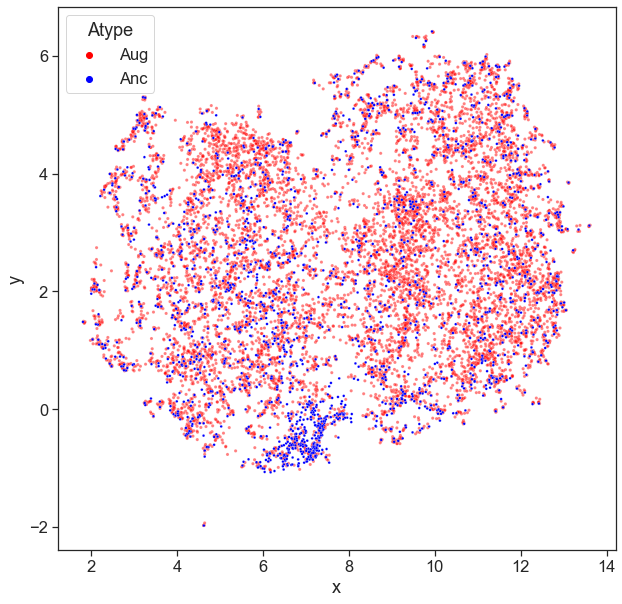

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041809_a04/29.pt!
Loaded evaluation data from /home/kat/Repos/SALSA/data/model_ready/01/test/anchor_smiles.csv!


  0%|          | 0/2000 [00:00<?, ?it/s]

Tag is 2022041809_a04_2000n_test_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022041809_a04_2000n_test_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022041809_a04_2000n_test_32neigh_mindist0pt1.png!


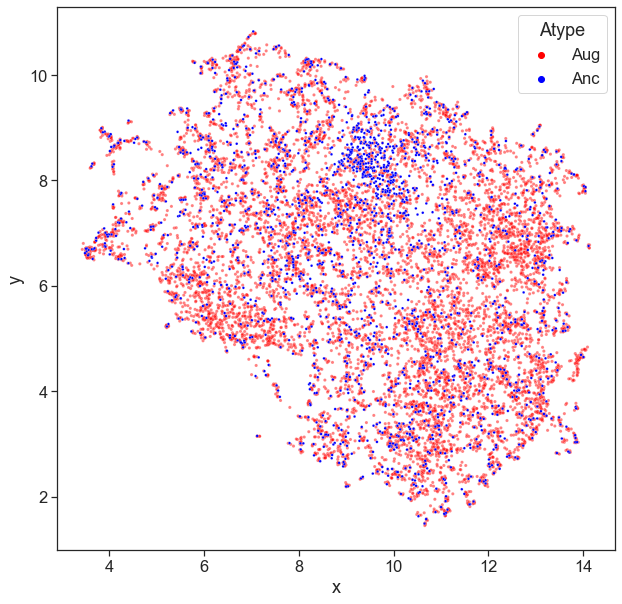

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041809_a04/29.pt!
Loaded evaluation data from /home/kat/Repos/SALSA/data/model_ready/01/test/anchor_smiles_ood.csv!


  0%|          | 0/2000 [00:00<?, ?it/s]

Tag is 2022041809_a04_2000n_ood_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022041809_a04_2000n_ood_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022041809_a04_2000n_ood_32neigh_mindist0pt1.png!


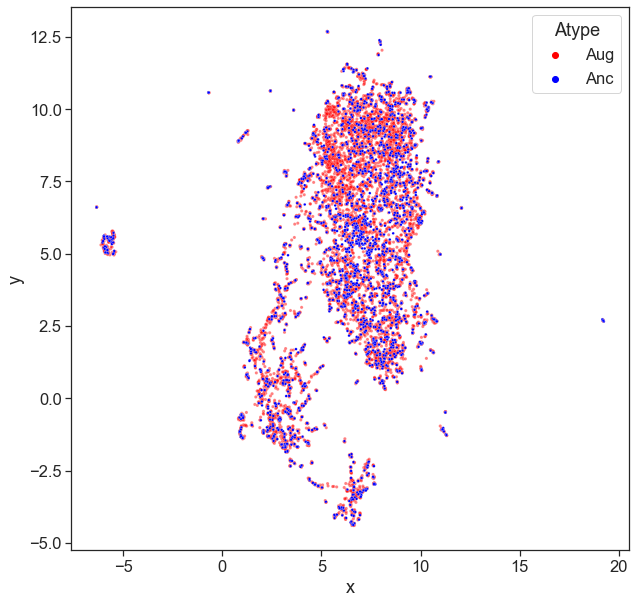

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041809_a04/29.pt!
Loaded evaluation data from /home/kat/Repos/SALSA/data/model_ready/01/test/anchor_smiles_extended.csv!


  0%|          | 0/2000 [00:00<?, ?it/s]

Tag is 2022041809_a04_12000n_extended_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022041809_a04_12000n_extended_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022041809_a04_12000n_extended_32neigh_mindist0pt1.png!


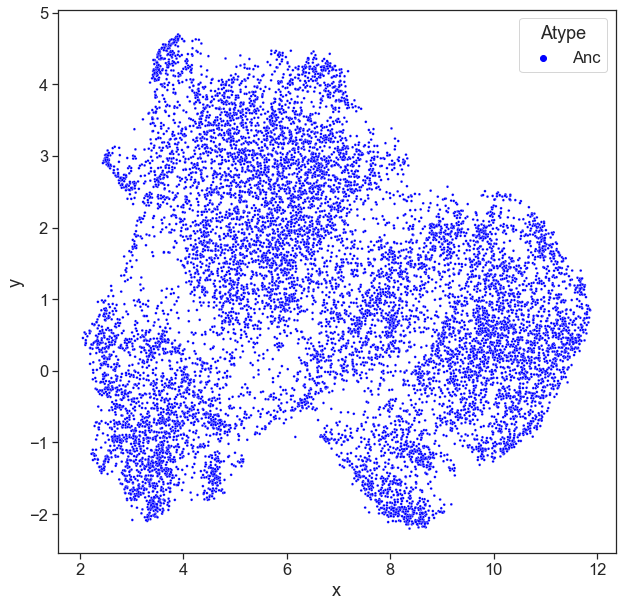

In [2]:
from eval_functions import *

# tag = '2022041804_04' 
# tag = '2022041807_a03' 
tag = '2022041809_a04'
param_list = [('train', False, False), # train set (2000*6)
              ('01', False, False),    # test set (2000*6)
              ('01', True, False),     # ood set (2000*6)
              ('01', False, True)]     # extended set (12000)

for params in param_list:
    
    which_test, test_ood, test_extended = params

    which_train = '01'
    samp_size = 2000
    if test_extended:
        samp_size = 12000
    n_epochs = 30

    eval_bs = 6
    use_cuda = True
    empty_cuda = True
    cuda_ids = [0,1,2,3]

    df, latents = get_df_and_latents(tag, which_train, which_test, test_ood, test_extended,
                                     samp_size, eval_bs, n_epochs, use_cuda, empty_cuda, cuda_ids)
    tag_emb = get_umap_tag(tag, which_test, test_ood, test_extended, samp_size)
    df_umap = get_umap_coords(tag_emb, df, latents, n_neighs=32, min_dist=0.1, 
                              save_coords=True, save_plot=True, show_plot=True)